# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset




## Setup

In [19]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [20]:
print(f"Số dòng và số cột: {df.shape}")
print(f"Danh sách tên cột: {df.columns.tolist()}")
print(f"Kiểu dữ liệu:\n{df.dtypes}")

Số dòng và số cột: (1338, 7)
Danh sách tên cột: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Kiểu dữ liệu:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


## A.2. Missing values & Duplicate data

In [21]:
print("Số giá trị thiếu ở mỗi cột:")
print(df.isnull().sum())

print(f"Số dòng trùng lặp (Duplicate): {df.duplicated().sum()}")

Số giá trị thiếu ở mỗi cột:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Số dòng trùng lặp (Duplicate): 1


## A.3. Invalid values

In [22]:
print(f"Số dòng có tuổi âm: {(df['age'] < 0).sum()}")
print(f"Số dòng có BMI âm: {(df['bmi'] < 0).sum()}")
print(f"Số dòng có chi phí âm: {(df['charges'] < 0).sum()}")

Số dòng có tuổi âm: 0
Số dòng có BMI âm: 0
Số dòng có chi phí âm: 0


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [23]:
dieu_kien = [
    (df['bmi'] < 25),
    (df['bmi'] >= 25) & (df['bmi'] < 30),
    (df['bmi'] >= 30)
]

ket_qua = ['Normal', 'Overweight', 'Obese']
df['bmi_group'] = np.select(dieu_kien, ket_qua, default='Unknown')

In [24]:
df

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [25]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


In [26]:
cols_num = ['age','bmi','children','charges']
for col in cols_num:
    mean_ = df[col].mean()
    median_ = df[col].median()
    mode_ = df[col].mode()[0]
    print(f"{col}: Mean = {mean_:.2f}, Median = {median_:.2f}, Mode = {mode_:.2f}")

cols_char = ['sex','smoker','region','bmi_group']
for col in cols_char:
    mode_ = df[col].mode()[0]
    print(f'{col} : {mode_}')    

age: Mean = 39.21, Median = 39.00, Mode = 18.00
bmi: Mean = 30.66, Median = 30.40, Mode = 32.30
children: Mean = 1.09, Median = 1.00, Mode = 0.00
charges: Mean = 13270.42, Median = 9382.03, Mode = 1639.56
sex : male
smoker : no
region : southeast
bmi_group : Obese


## Group 2 — Dispersion

In [27]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


In [28]:
for col in ['age', 'bmi', 'charges']:
    s = df[col]

    range_ = s.max() - s.min()
    std_ = s.std()
    var_ = s.var()

    #iqr
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr_ = q3 - q1

    cv_ = std_ / s.mean()
    
    print(f"--- {col} ---")
    print(f"Range: {range_:.2f},Var: {var_:.2}, Std: {std_:.2f}, IQR: {iqr_:.2f}, CV: {cv_:.2f}")

--- age ---
Range: 46.00,Var: 2e+02, Std: 14.05, IQR: 24.00, CV: 0.36
--- bmi ---
Range: 37.17,Var: 3.7e+01, Std: 6.10, IQR: 8.40, CV: 0.20
--- charges ---
Range: 62648.55,Var: 1.5e+08, Std: 12110.01, IQR: 11899.63, CV: 0.91


## Group 3 — Location and Shape

--- age ---
P25=27.00, P50=39.00, P75=51.00
Skewness=0.06, Kurtosis=-1.24
--- bmi ---
P25=26.30, P50=30.40, P75=34.69
Skewness=0.28, Kurtosis=-0.06
--- charges ---
P25=4740.29, P50=9382.03, P75=16639.91
Skewness=1.51, Kurtosis=1.60


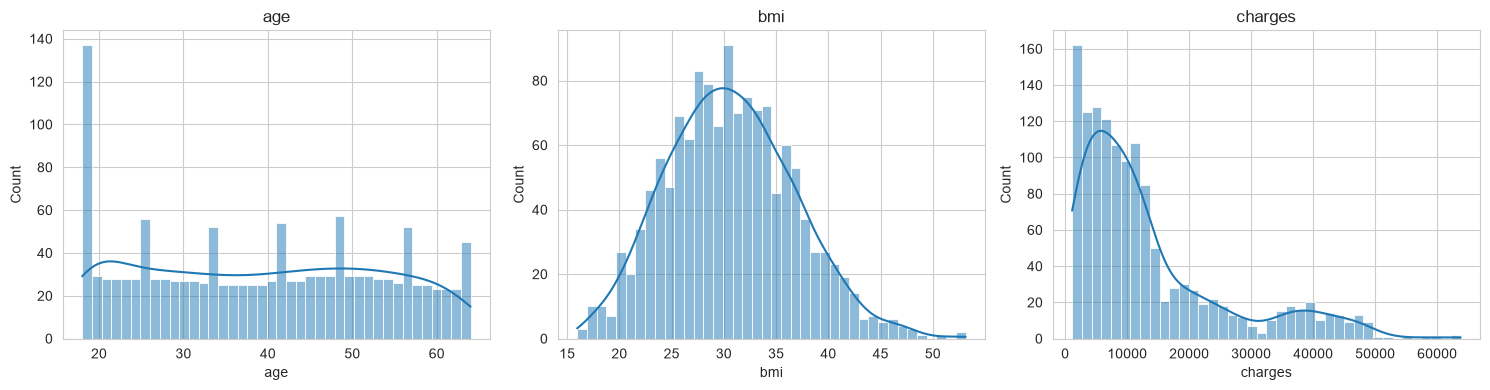

==> Nhận xét: 
1.Age: độ tuổi từ 20 đến 6 phân bố khá đều nhau, tuy nhiên có 1 cột ở độ tuổi từ 18-19 tuổi thì cao một cách bất ngờ. Từ đó cho thấy nhóm thanh niên trẻ tuổi mới tham gia bảo hiểm chiếm số lượng đông đảo nhất
2.Bmi: Hình dạng của biểu đồ bmi khá đồng đều và số người đạt chỉ số bmi 30 là nhiều nhất.Số lượng người quá gầyhoặc béo phì nặng giảm dần đều về hai bên
3. Charges: phần lớn dữ liệu dồn về bên trái cho thấy phân lớn khách hành phải trả chi phí khá rẻ cho bảo hiểm. Nhưng ĐUôi đồ thị kéo dài tới 6000$, cho thấy có 1 số ít khách hàng phải trả một chi phí rất đắt đỏ cho tiền bảo hiểm (~6000$)


In [36]:
for col in ['age','bmi','charges']:
    s = df[col]
    skew_,kurt_ = stats.skew(s),stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")
fig,axes = plt.subplots(1,3,figsize=(15,4))
sns.histplot(df['age'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('age')
sns.histplot(df['bmi'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('bmi')
sns.histplot(df['charges'],bins=40,kde=True,ax=axes[2]); axes[2].set_title('charges')
plt.tight_layout(); 
plt.show()

print('==> Nhận xét: ' \
            '\n1.Age: độ tuổi từ 20 đến 6 phân bố khá đều nhau, tuy nhiên có 1 cột ở độ tuổi từ 18-19 tuổi thì cao một cách bất ngờ. Từ đó cho thấy nhóm thanh niên trẻ tuổi mới tham gia bảo hiểm chiếm số lượng đông đảo nhất' \
            '\n2.Bmi: Hình dạng của biểu đồ bmi khá đồng đều và số người đạt chỉ số bmi 30 là nhiều nhất.Số lượng người quá gầyhoặc béo phì nặng giảm dần đều về hai bên' \
            '\n3. Charges: phần lớn dữ liệu dồn về bên trái cho thấy phân lớn khách hành phải trả chi phí khá rẻ cho bảo hiểm. Nhưng ĐUôi đồ thị kéo dài tới 6000$, cho thấy có 1 số ít khách hàng phải trả một chi phí rất đắt đỏ cho tiền bảo hiểm (~6000$)')

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [37]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


In [44]:
smoker_cost = df.groupby('smoker')['charges'].mean()
display(smoker_cost.round(2))
ty_le = smoker_cost['yes'] / smoker_cost['no']
print(f"tỉ lệ người hút thuốc trả tiền nhiều hơn người khoogn hút thuốc là: {ty_le:.2f}")

region_smoker = df.pivot_table(index='region', columns='smoker', values='charges', aggfunc='mean')
display(region_smoker.round(2))

smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64

tỉ lệ người hút thuốc trả tiền nhiều hơn người khoogn hút thuốc là: 3.80


smoker,no,yes
region,,
northeast,9165.53,29673.54
northwest,8556.46,30192.00
southeast,8032.22,34845.00
southwest,8019.28,32269.06


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [53]:
df_smoker = df[df['smoker'] == 'yes']
df_nonsmoker = df[df['smoker'] == 'no']

display(df_smoker)
display(df_nonsmoker)

## Đô tương quan
corr_smoker = df_smoker['bmi'].corr(df_smoker['charges'])
corr_nonsmoker = df_nonsmoker['bmi'].corr(df_nonsmoker['charges'])

print(f"Đôj tương quan giữa chi phí và BMI nhóm người hút thuốc: {corr_smoker:.2f}")
print(f"Độ tương quan giữa chi phí và BMI nhóm người không hút thuốc: {corr_nonsmoker:.2f}")

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
11,62,female,26.290,0,yes,southeast,27808.72510,Overweight
14,27,male,42.130,0,yes,southeast,39611.75770,Obese
19,30,male,35.300,0,yes,southwest,36837.46700,Obese
23,34,female,31.920,1,yes,northeast,37701.87680,Obese
...,...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600,Obese
1314,30,female,23.655,3,yes,northwest,18765.87545,Normal
1321,62,male,26.695,0,yes,northeast,28101.33305,Overweight
1323,42,female,40.370,2,yes,southeast,43896.37630,Obese


,age,sex,bmi,children,smoker,region,charges,bmi_group
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
5,31,female,25.740,0,no,southeast,3756.62160,Overweight
...,...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500,Obese
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese


Đôj tương quan giữa chi phí và BMI nhóm người hút thuốc: 0.81
Độ tương quan giữa chi phí và BMI nhóm người không hút thuốc: 0.08


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [64]:
region_cost = df.groupby('region')['charges'].mean().sort_values(ascending=False)

print("--CHI PHÍ TRUNG BÌNH THEO VÙNG")
display(region_cost)
print('VÙNG CÓ CHI PHÍ BẢO HIỂM TRUNG BÌNH CAO NHẤT')
display(region_cost.head(1))

--CHI PHÍ TRUNG BÌNH THEO VÙNG


region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64

VÙNG CÓ CHI PHÍ BẢO HIỂM TRUNG BÌNH CAO NHẤT


region
southeast    14735.411438
Name: charges, dtype: float64

## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [54]:
number_of_children = df.groupby('children')['charges'].mean()

display(number_of_children)

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [58]:
tq_tuoi_chiphi = df['age'].corr(df['charges'])

print(f'Độ tương quan tuổi và chi phí bảo hiểm: {tq_tuoi_chiphi:.2f}')

Độ tương quan tuổi và chi phí bảo hiểm: 0.30


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

1. Yếu tố ảnh hưởng lớn nhất đến chi phí bảo hiểm là hút thuốc. Chi phí của người hút thuốc phải chi trả cao gần gấp 4 lần so với người không hút thuuoocs
2. Chỉ số BMI không có độ tương quan mạnh với nhóm người hút thuốc.Nhưng với người có chỉ số BMI cao thì họ phải chi trả chi phí bảo hiểm cao hơn rất nhiều
3. Các yếu tố như con cái, vùng miền và tuổi tác thì có vẻ là không có tác động quá lớn đến số tiền chi trả bảo hiểm, sự chênh lệch đó không quá đangs kể.

